In [1]:
import os
import tqdm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import time
import tm
import tqdm
import copy
import sys
import datasetutils
plt.style.use('dark_background') # i prefer this color scheme but need to install. coment if not working

In [2]:
#import importlib
#importlib.reload(tm)

In [7]:

n = 1000
x = np.random.normal(0, 0.01, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,0.01,n)
df1 = pd.DataFrame()
df1['x'] = x
df1['y'] = y
df1.index = pd.date_range('2000-01-01', freq = 'D', periods = n)

n = 1000
x = np.random.normal(0, 0.03, n)
a = 0
b = 0.2
y = a+b*x+np.random.normal(0,0.03,n)
df2 = pd.DataFrame()
df2['y'] = y
df2['x'] = x
df2.index = pd.date_range('2002-01-01', freq = 'D', periods = n)


dataset = tm.Dataset()
dataset.add('strat1', df1)
dataset.add('strat2', df2)

model_set = tm.ModelSet()

base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal()
model1 = tm.Model(base_model = base_model, allocation = alloc)   
model_set.add('strat1', model1)     


base_model = tm.base.LinRegr()
alloc = tm.allocation.Optimal()
model2 = tm.Model(base_model = base_model, allocation = alloc)   
model_set.add('strat2', model2)    


model_set.estimate(dataset) 
model_set.view()



******* ModelSet *******



-> For key strat1


* Model *
** Linear Regression **
Weights:  [-1.85114439e-04  2.94335479e-01]
Variance:  9.696439749115943e-05


k:  43.86892055947449
Weight mean:  [0.]



-> For key strat2


* Model *
** Linear Regression **
Weights:  [-3.23293029e-05  2.37100374e-01]
Variance:  0.0008940337963818241


k:  43.86892055947449
Weight mean:  [0.]


*************************


In [8]:
# 3 - RUN CVBT
# this part is always the same and is easy
paths = tm.cvbt(
        dataset = dataset, 
        modelset = model_set,            
        n_paths = 1,
        k_folds = 4, 
        seq_path = False, 
        start_fold = 0, 
        burn_fraction = 0.1, 
        min_burn_points = 3,
        view_after_estimate = False
        )


100%|████████████████████████████████████████████████████████████████████████████████████| 1/1 [00:00<00:00,  8.91it/s]


In [9]:
paths

[{'strat1':                    y         x  msidx         s       pw  w_y
  2000-01-01  0.002614 -0.007075    0.0 -0.002614  0.49541 -1.0
  2000-01-02  0.010428  0.019180    0.0  0.010428  0.49541  1.0
  2000-01-03 -0.001392  0.001511    0.0 -0.001392  0.49541  1.0
  2000-01-04  0.003037 -0.005916    0.0 -0.003037  0.49541 -1.0
  2000-01-05 -0.011728 -0.004221    0.0  0.011728  0.49541 -1.0
  ...              ...       ...    ...       ...      ...  ...
  2002-09-22  0.007957  0.007570    0.0  0.007957  0.62602  1.0
  2002-09-23  0.000923  0.006221    0.0  0.000923  0.62602  1.0
  2002-09-24 -0.020190 -0.025770    0.0  0.020190  0.62602 -1.0
  2002-09-25 -0.003963 -0.012478    0.0  0.003963  0.62602 -1.0
  2002-09-26  0.005737  0.006977    0.0  0.005737  0.62602  1.0
  
  [1000 rows x 6 columns],
  'strat2':                    y         x  msidx         s        pw       w_y
  2002-01-01 -0.009737  0.012676    0.0 -0.002416  0.496223  0.248168
  2002-01-02  0.017224 -0.002396    0.0 -0

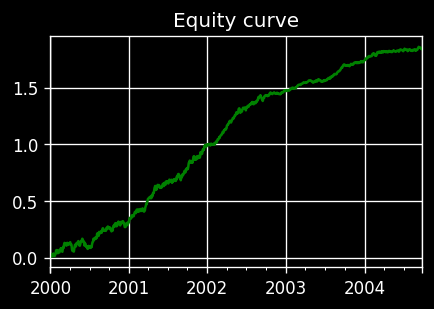

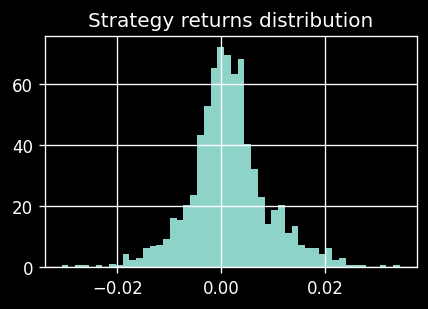

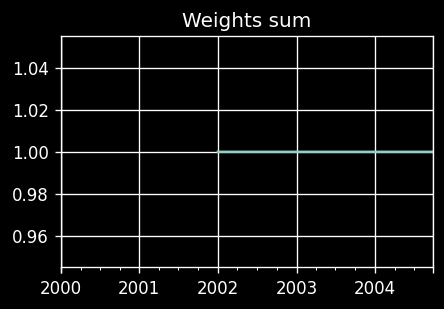

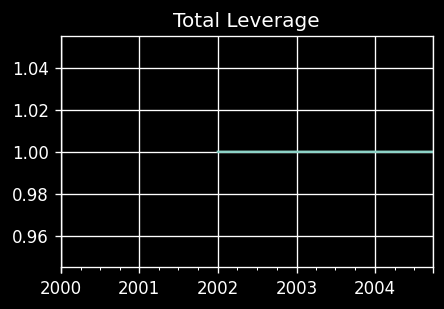

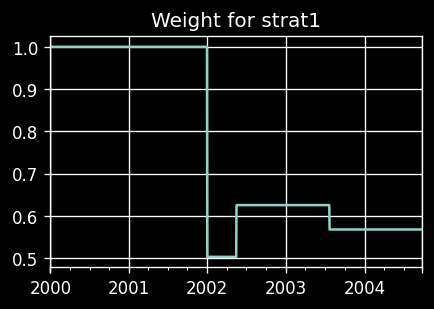

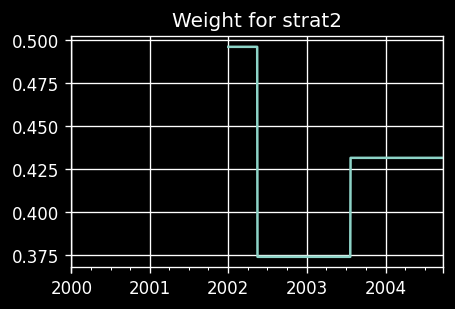

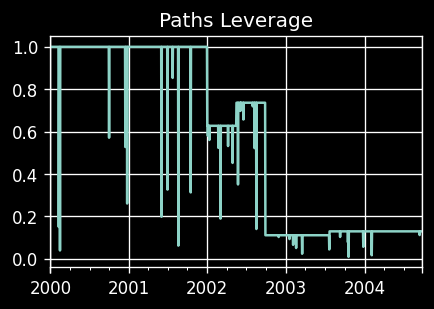

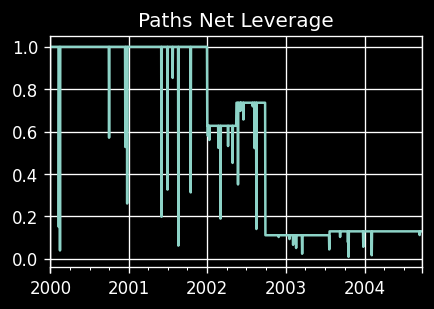

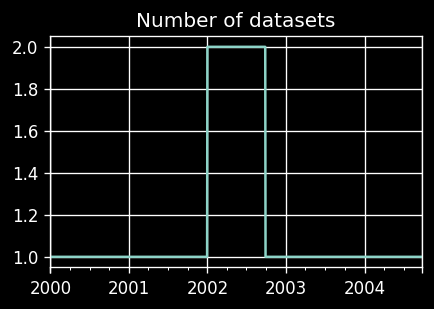

** ACCEPT STRATEGY from normal approximation of bootstrap Sharpe [alpha = 5e-05]**


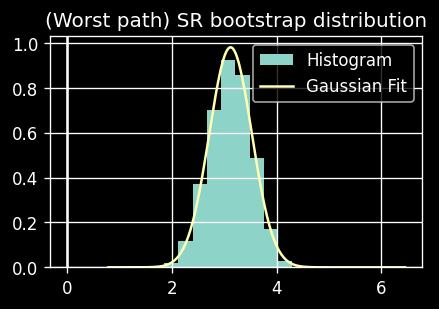


** PERFORMANCE SUMMARY **

Return:  0.37198401029020006
Standard deviation:  0.12033138467004018
Sharpe:  3.0913299245264625



,path_1
1999-12-31,0.010428
2000-01-03,-0.001392
2000-01-04,-0.003037
2000-01-05,0.011728
2000-01-06,-0.004966
...,...
2004-09-20,-0.006141
2004-09-21,-0.002546
2004-09-22,0.003041
2004-09-23,-0.003851


In [10]:
paths.portfolio_post_process(pct_fee = 0)
